# Experiment 8 — Capping: Theoretical vs Empirical Optimal Threshold $c^*$

**Setup:** Control $X \sim \text{Lomax}$ (Pareto Type II, heavy tail), Treatment $Y = X + \tau(X)$.  
A/B test: $N$ users randomly assigned 50/50 to control or treatment; each user is observed in exactly one arm.  
Cap both arms at $c$: $X_c = \min(X,c)$, $Y_c = \min(Y,c)$.

$$\text{SNR}(c) = \frac{f(c)}{\sqrt{V(c)}}, \quad f(c)=E[Y_c]-E[X_c], \quad V(c)=\text{Var}(X_c)$$

**Theoretical FOC** (first-order condition for $c^*$):
$$f'(c^*)\cdot V(c^*) = f(c^*)\cdot \bar{F}(c^*)\cdot(c^* - \mu(c^*))$$
where $\mu(c)=E[X_c]=\int_0^c\bar{F}(u)\,du$ and $V(c)=2\int_0^c u\bar{F}(u)\,du - \mu(c)^2$.

| Effect | $f(c)$ | $f'(c)$ |
|---|---|---|
| Constant $\tau$ | $\int_{c-\tau}^{c}F(u)\,du$ | $\bar{F}(c-\tau)-\bar{F}(c)$ |
| Linear $\alpha$ | $(1+\alpha)\mu(c/(1+\alpha))-\mu(c)$ | $\bar{F}(c/(1+\alpha))-\bar{F}(c)$ |

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, integrate, optimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Generate A/B Test Dataset (Heavy-Tail Distribution)

Distribution: Lomax(c=2.5, scale=3.0)  [mean=2.00, std=4.47]
A/B split:  control n=49,834  |  treatment n=50,166
Observed control:              mean=1.983,  std=4.159
Observed treatment (const τ=0.2):  mean=2.178
Observed treatment (lin  α=0.2): mean=2.373
c_grid lower bound ≈ 0.562  >  TAU=0.2  ✓


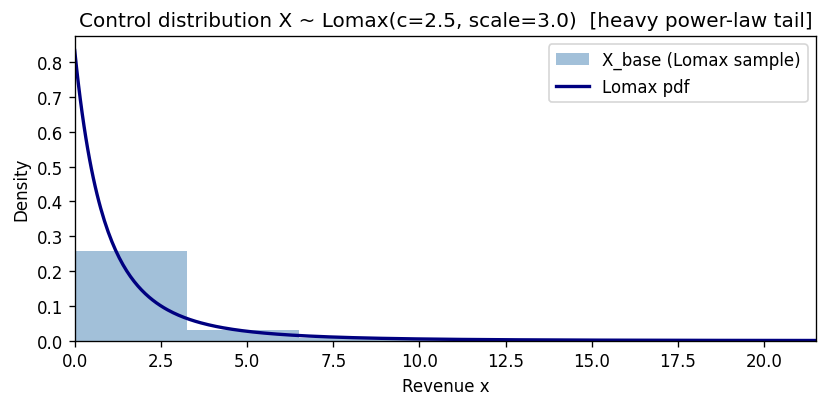

In [31]:
N = 100_000

# Lomax (Pareto Type II) — heavy power-law tail, support [0, ∞)
# mean = scale/(c-1) = 2.0 ;  var = scale²·c/((c-1)²·(c-2)) = 20.0
LOMAX_C, LOMAX_SCALE = 2.5, 3.0
dist = stats.lomax(c=LOMAX_C, scale=LOMAX_SCALE)

# Treatment effects.
# TAU is kept below the 35th-pct of Lomax (≈ 0.53) so every c in c_grid
# satisfies c > TAU — this prevents the degenerate Var(Y_c)=0 regime that
# pins power to 1.0 regardless of the cap choice.
TAU   = 0.2    # constant additive lift  (~10 % of mean)
ALPHA = 0.20   # linear multiplicative lift (20%)

# Sample N latent "potential control" values from the heavy-tail distribution
X_base = dist.rvs(N)

# Potential outcomes for every user under each effect type
trt_const = X_base + TAU
trt_lin   = (1 + ALPHA) * X_base

# Random 50/50 A/B assignment  (0 = control, 1 = treatment)
assignment = np.random.binomial(1, 0.5, N)
ctrl_mask, trt_mask = assignment == 0, assignment == 1

# Observed values in each arm — the N-row potential-outcomes table
obs_ctrl      = X_base[ctrl_mask]        # control arm  (~N/2)
obs_trt_const = trt_const[trt_mask]      # treatment arm, constant effect (~N/2)
obs_trt_lin   = trt_lin[trt_mask]        # treatment arm, linear effect   (~N/2)

print(f"Distribution: Lomax(c={LOMAX_C}, scale={LOMAX_SCALE})  "
      f"[mean={dist.mean():.2f}, std={dist.std():.2f}]")
print(f"A/B split:  control n={ctrl_mask.sum():,}  |  treatment n={trt_mask.sum():,}")
print(f"Observed control:              mean={obs_ctrl.mean():.3f},  std={obs_ctrl.std():.3f}")
print(f"Observed treatment (const τ={TAU}):  mean={obs_trt_const.mean():.3f}")
print(f"Observed treatment (lin  α={ALPHA}): mean={obs_trt_lin.mean():.3f}")
print(f"c_grid lower bound ≈ {np.percentile(obs_ctrl, 35):.3f}  >  TAU={TAU}  ✓")

fig, ax = plt.subplots(figsize=(7, 3.5))
p995 = np.percentile(X_base, 99.5)
x_plot = np.linspace(0, p995, 400)
ax.hist(X_base, bins=100, density=True, alpha=0.5, color='steelblue', label='X_base (Lomax sample)')
ax.plot(x_plot, dist.pdf(x_plot), 'navy', lw=2, label='Lomax pdf')
ax.set_xlim(0, p995)
ax.set_xlabel('Revenue x'); ax.set_ylabel('Density')
ax.set_title(f'Control distribution X ~ Lomax(c={LOMAX_C}, scale={LOMAX_SCALE})  [heavy power-law tail]')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Theoretical Quantities (Analytical, True Distribution)

In [32]:
# ── Shared: capped moments of X ──────────────────────────────────────────────

def mu_cap(c):
    """E[min(X,c)] = ∫₀ᶜ S(u) du   (survival-function formula)"""
    v, _ = integrate.quad(dist.sf, 0, c, limit=200)
    return v

def V_cap(c):
    """Var(min(X,c)) = 2∫₀ᶜ u·S(u) du − μ_cap(c)²"""
    m2, _ = integrate.quad(lambda u: 2*u*dist.sf(u), 0, c, limit=200)
    return m2 - mu_cap(c)**2

# ── Constant effect τ ─────────────────────────────────────────────────────────

def f_cap_const(c, tau=TAU):
    """f(c) = ∫_{c-τ}^{c} F(u) du"""
    lo = max(c - tau, 0.0)
    v, _ = integrate.quad(dist.cdf, lo, c, limit=200)
    return v

def f_prime_cap_const(c, tau=TAU):
    """f'(c) = F(c) − F(c−τ) = S(c−τ) − S(c)"""
    return dist.cdf(c) - dist.cdf(max(c - tau, 0.0))

def foc_cap_const(c, tau=TAU):
    """FOC residual = f'·V − f·S·(c−μ).  Zero at c*."""
    return (f_prime_cap_const(c, tau) * V_cap(c)
            - f_cap_const(c, tau) * dist.sf(c) * (c - mu_cap(c)))

# ── Linear effect Y=(1+α)X ────────────────────────────────────────────────────

def f_cap_lin(c, alpha=ALPHA):
    """f(c) = (1+α)·μ_cap(c/(1+α)) − μ_cap(c)"""
    return (1 + alpha) * mu_cap(c / (1 + alpha)) - mu_cap(c)

def f_prime_cap_lin(c, alpha=ALPHA):
    """f'(c) = S(c/(1+α)) − S(c)"""
    return dist.sf(c / (1 + alpha)) - dist.sf(c)

def foc_cap_lin(c, alpha=ALPHA):
    """FOC residual = f'·V − f·S·(c−μ).  Zero at c*."""
    return (f_prime_cap_lin(c, alpha) * V_cap(c)
            - f_cap_lin(c, alpha) * dist.sf(c) * (c - mu_cap(c)))

# ── Theoretical SNR curve ─────────────────────────────────────────────────────

def snr_cap_theory_const(c, tau=TAU):
    v = V_cap(c)
    return f_cap_const(c, tau) / np.sqrt(v) if v > 0 else 0.0

def snr_cap_theory_lin(c, alpha=ALPHA):
    v = V_cap(c)
    return f_cap_lin(c, alpha) / np.sqrt(v) if v > 0 else 0.0

print("Theoretical functions defined.")

Theoretical functions defined.


## 3. Find Theoretical $c^*$ via Root-Finding on FOC

In [33]:
c_scan = np.linspace(dist.ppf(0.05), dist.ppf(0.9995), 600)

# Evaluate FOC residuals over grid
foc_scan_const = np.array([foc_cap_const(c) for c in c_scan])
foc_scan_lin   = np.array([foc_cap_lin(c)   for c in c_scan])

def first_sign_change_bracket(vals, grid):
    """Return (a, b) where FOC changes sign from + to −."""
    for i in range(len(vals) - 1):
        if vals[i] > 0 and vals[i+1] < 0:
            return grid[i], grid[i+1]
    raise ValueError("No sign change found — check grid bounds.")

a_const, b_const = first_sign_change_bracket(foc_scan_const, c_scan)
a_lin,   b_lin   = first_sign_change_bracket(foc_scan_lin,   c_scan)

c_star_theory_const = optimize.brentq(foc_cap_const, a_const, b_const, xtol=1e-6)
c_star_theory_lin   = optimize.brentq(foc_cap_lin,   a_lin,   b_lin,   xtol=1e-6)

print(f"Theoretical c* — Constant effect (τ={TAU}):  {c_star_theory_const:.4f}")
print(f"Theoretical c* — Linear effect  (α={ALPHA}): {c_star_theory_lin:.4f}")

print(f"\nFOC residual check:")
print(f"  Constant: foc(c*)={foc_cap_const(c_star_theory_const):.2e}")
print(f"  Linear:   foc(c*)={foc_cap_lin(c_star_theory_lin):.2e}")

Theoretical c* — Constant effect (τ=0.2):  0.2922
Theoretical c* — Linear effect  (α=0.2): 5.4429

FOC residual check:
  Constant: foc(c*)=-1.97e-10
  Linear:   foc(c*)=-4.52e-10


## 4. Empirical $c^*$ via Grid Search on Samples

In [34]:
c_grid = np.linspace(np.percentile(obs_ctrl, 10), np.percentile(obs_ctrl, 99.9), 300)

def empirical_curves(c_values, Xarr, Yarr):
    """SNR and two-sample t-stat at each cap threshold, computed in one pass."""
    snr = np.empty(len(c_values))
    tst = np.empty(len(c_values))
    for i, c in enumerate(c_values):
        Xc = np.minimum(Xarr, c)
        Yc = np.minimum(Yarr, c)
        diff = Yc.mean() - Xc.mean()
        v    = Xc.var(ddof=1)
        snr[i] = diff / np.sqrt(v) if v > 0 else 0.0
        t, _   = stats.ttest_ind(Yc, Xc, equal_var=True)
        tst[i] = t
    return snr, tst

# Constant effect
snr_emp_const, tstat_emp_const = empirical_curves(c_grid, obs_ctrl, obs_trt_const)
c_star_snr_const   = c_grid[np.argmax(snr_emp_const)]
c_star_tstat_const = c_grid[np.argmax(tstat_emp_const)]

# Linear effect
snr_emp_lin, tstat_emp_lin = empirical_curves(c_grid, obs_ctrl, obs_trt_lin)
c_star_snr_lin   = c_grid[np.argmax(snr_emp_lin)]
c_star_tstat_lin = c_grid[np.argmax(tstat_emp_lin)]

# Theoretical SNR curves (analytical)
snr_theory_const = np.array([snr_cap_theory_const(c) for c in c_scan])
snr_theory_lin   = np.array([snr_cap_theory_lin(c)   for c in c_scan])

# ── True power curves via Monte Carlo ─────────────────────────────────────────
# n_pw=50 per arm: at this scale the power at c* ≈ 0.7, giving visible
# bell-shaped variation.  n=200+ saturates to 1.0 for this effect size.
B_pw, n_pw = 500, 50
X_pw       = dist.rvs((B_pw, n_pw))
Y_pw_const = X_pw + TAU
Y_pw_lin   = (1 + ALPHA) * X_pw

def compute_power_curve(c_values, X_sims, Y_sims, alpha=0.05):
    """Fraction of simulated t-tests that reject H₀ at each cap threshold."""
    n      = X_sims.shape[1]
    t_crit = stats.t.ppf(1 - alpha / 2, df=2 * n - 2)
    powers = np.empty(len(c_values))
    for i, c in enumerate(c_values):
        Xc   = np.minimum(X_sims, c)
        Yc   = np.minimum(Y_sims, c)
        diff = Yc.mean(axis=1) - Xc.mean(axis=1)
        sp2  = (Xc.var(axis=1, ddof=1) + Yc.var(axis=1, ddof=1)) / 2
        t    = diff / np.sqrt(sp2 * 2 / n)
        powers[i] = np.mean(np.abs(t) > t_crit)
    return powers

power_const = compute_power_curve(c_grid, X_pw, Y_pw_const)
power_lin   = compute_power_curve(c_grid, X_pw, Y_pw_lin)

print(f"{'Method':<26} {'Constant τ='+str(TAU):>14} {'Linear α='+str(ALPHA):>14}")
print("-" * 56)
print(f"{'Theoretical FOC c*':<26} {c_star_theory_const:>14.4f} {c_star_theory_lin:>14.4f}")
print(f"{'Empirical max-SNR c*':<26} {c_star_snr_const:>14.4f} {c_star_snr_lin:>14.4f}")
print(f"{'Empirical max-t c*':<26} {c_star_tstat_const:>14.4f} {c_star_tstat_lin:>14.4f}")
print(f"\nPower at max-t c*:  const={power_const[np.argmax(tstat_emp_const)]:.3f}"
      f"  lin={power_lin[np.argmax(tstat_emp_lin)]:.3f}")

Method                     Constant τ=0.2   Linear α=0.2
--------------------------------------------------------
Theoretical FOC c*                 0.2922         5.4429
Empirical max-SNR c*               0.2801         6.8166
Empirical max-t c*                 0.2801         5.1825

Power at max-t c*:  const=0.932  lin=0.000


## 5. Visualization

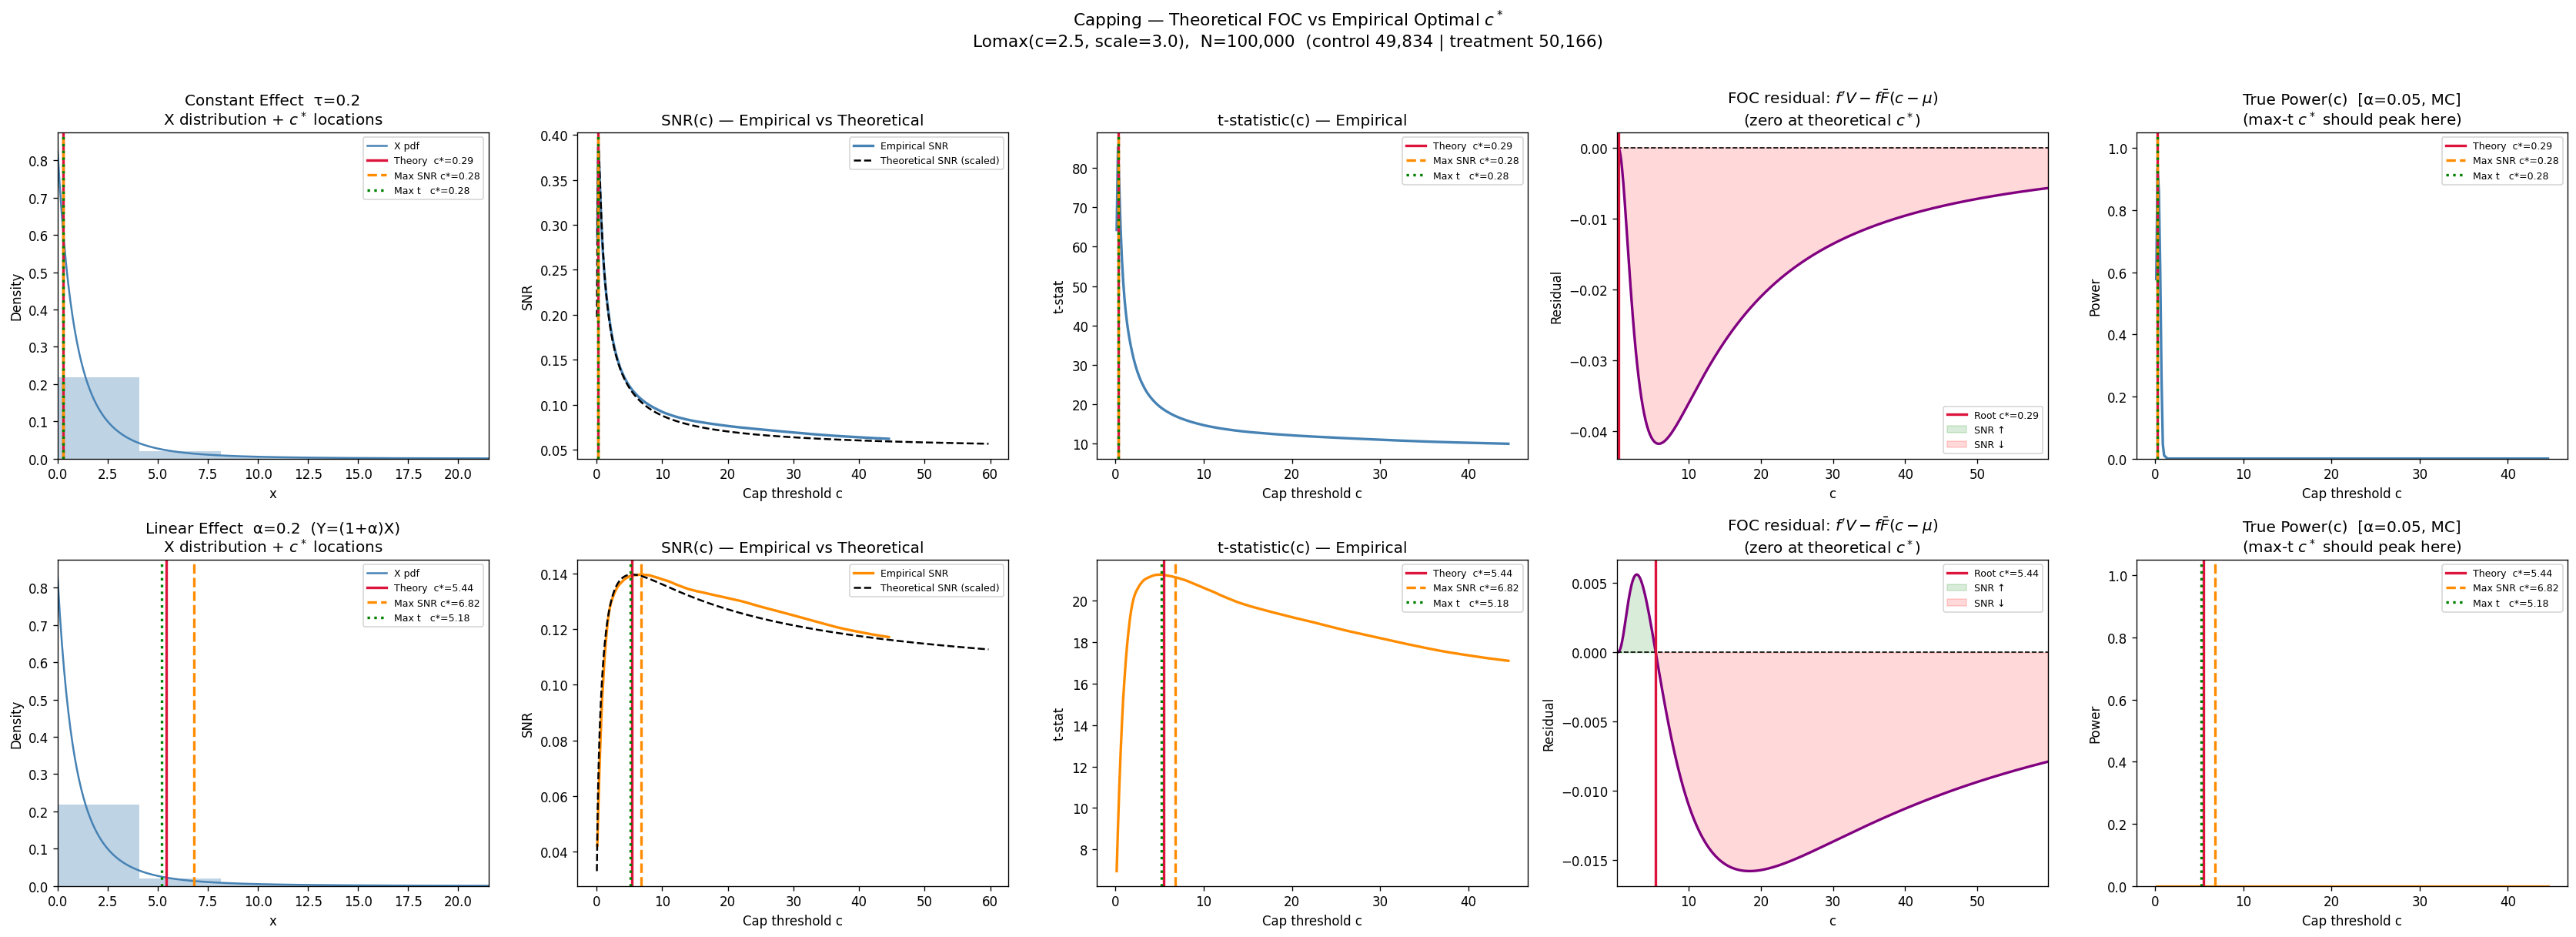

In [35]:
def plot_capping_case(axes_row, X_base, c_grid, c_scan,
                      snr_emp, tstat_emp, snr_theory, foc_scan, power_emp,
                      c_theory, c_snr, c_tstat,
                      title, row_color):
    """5-panel row: histogram | SNR | t-stat | FOC residual | power curve."""
    ax_hist, ax_snr, ax_t, ax_foc, ax_pw = axes_row
    vlines = [
        (c_theory, 'crimson',    '-',  f'Theory  c*={c_theory:.2f}'),
        (c_snr,    'darkorange', '--', f'Max SNR c*={c_snr:.2f}'),
        (c_tstat,  'green',      ':',  f'Max t   c*={c_tstat:.2f}'),
    ]

    # ── Histogram ────────────────────────────────────────────────────
    p995   = np.percentile(X_base, 99.5)
    x_plot = np.linspace(0, p995, 400)
    ax_hist.hist(X_base, bins=80, density=True, alpha=0.35, color='steelblue')
    ax_hist.plot(x_plot, dist.pdf(x_plot), 'steelblue', lw=1.5, label='X pdf')
    for cv, col, ls, lbl in vlines:
        ax_hist.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_hist.set_xlim(0, p995)
    ax_hist.set_title(f'{title}\nX distribution + $c^*$ locations')
    ax_hist.set_xlabel('x'); ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=7.5)

    # ── SNR curves: empirical + theoretical ──────────────────────────
    scale = snr_emp.max() / snr_theory.max() if snr_theory.max() > 0 else 1
    ax_snr.plot(c_grid, snr_emp,            color=row_color, lw=2,   label='Empirical SNR')
    ax_snr.plot(c_scan, snr_theory * scale, color='black',   lw=1.5,
                linestyle='--', label='Theoretical SNR (scaled)')
    for cv, col, ls, lbl in vlines:
        ax_snr.axvline(cv, color=col, lw=2, linestyle=ls)
    ax_snr.set_title('SNR(c) — Empirical vs Theoretical')
    ax_snr.set_xlabel('Cap threshold c'); ax_snr.set_ylabel('SNR')
    ax_snr.legend(fontsize=7.5)

    # ── t-stat curve ─────────────────────────────────────────────────
    ax_t.plot(c_grid, tstat_emp, color=row_color, lw=2)
    for cv, col, ls, lbl in vlines:
        ax_t.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_t.set_title('t-statistic(c) — Empirical')
    ax_t.set_xlabel('Cap threshold c'); ax_t.set_ylabel('t-stat')
    ax_t.legend(fontsize=7.5)

    # ── FOC residual ─────────────────────────────────────────────────
    ax_foc.plot(c_scan, foc_scan, color='purple', lw=2)
    ax_foc.axhline(0, color='k', lw=1, linestyle='--')
    ax_foc.axvline(c_theory, color='crimson', lw=2, linestyle='-',
                   label=f'Root c*={c_theory:.2f}')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan > 0), alpha=0.15, color='green', label='SNR ↑')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan < 0), alpha=0.15, color='red',   label='SNR ↓')
    ax_foc.set_title("FOC residual: $f'V - f\\bar{F}(c-\\mu)$\n(zero at theoretical $c^*$)")
    ax_foc.set_xlabel('c'); ax_foc.set_ylabel('Residual')
    ax_foc.set_xlim(c_scan[0], c_scan[-1])
    ax_foc.legend(fontsize=7.5)

    # ── True power curve ─────────────────────────────────────────────
    ax_pw.plot(c_grid, power_emp, color=row_color, lw=2)
    for cv, col, ls, lbl in vlines:
        ax_pw.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_pw.set_title('True Power(c)  [α=0.05, MC]\n(max-t $c^*$ should peak here)')
    ax_pw.set_xlabel('Cap threshold c'); ax_pw.set_ylabel('Power')
    ax_pw.set_ylim(0, 1.05)
    ax_pw.legend(fontsize=7.5)


fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle(
    'Capping — Theoretical FOC vs Empirical Optimal $c^*$\n'
    f'Lomax(c={LOMAX_C}, scale={LOMAX_SCALE}),  N={N:,}  '
    f'(control {ctrl_mask.sum():,} | treatment {trt_mask.sum():,})',
    fontsize=13, y=1.01)

plot_capping_case(
    axes[0], X_base, c_grid, c_scan,
    snr_emp_const, tstat_emp_const, snr_theory_const, foc_scan_const, power_const,
    c_star_theory_const, c_star_snr_const, c_star_tstat_const,
    f'Constant Effect  τ={TAU}', 'steelblue')

plot_capping_case(
    axes[1], X_base, c_grid, c_scan,
    snr_emp_lin, tstat_emp_lin, snr_theory_lin, foc_scan_lin, power_lin,
    c_star_theory_lin, c_star_snr_lin, c_star_tstat_lin,
    f'Linear Effect  α={ALPHA}  (Y=(1+α)X)', 'darkorange')

plt.tight_layout()
plt.savefig('capping_main.png', dpi=150, bbox_inches='tight')
plt.show()

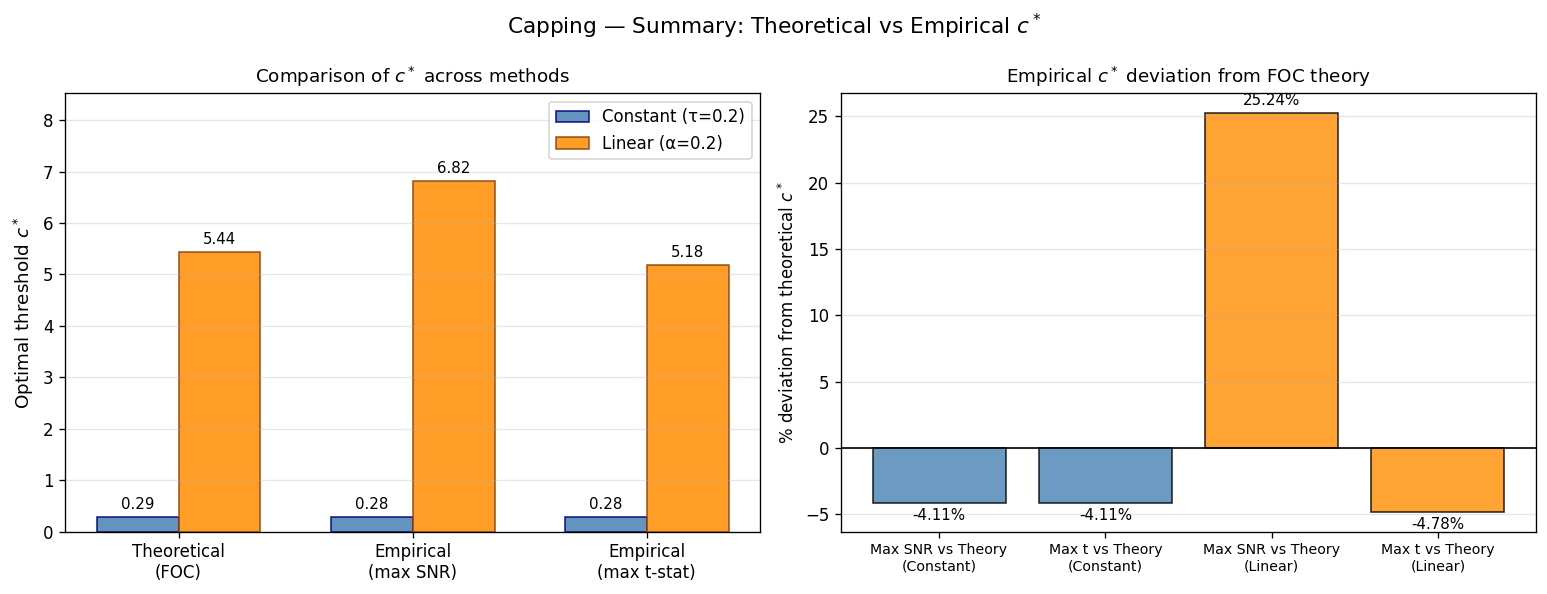


── Final Summary ──
Constant effect (τ=0.2):
  Theory c*=0.2922 | max-SNR c*=0.2801 (-4.11%) | max-t c*=0.2801 (-4.11%)
Linear effect (α=0.2):
  Theory c*=5.4429 | max-SNR c*=6.8166 (+25.24%) | max-t c*=5.1825 (-4.78%)


In [36]:
# ── Summary: bar chart + scatter comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Capping — Summary: Theoretical vs Empirical $c^*$', fontsize=13)

methods = ['Theoretical\n(FOC)', 'Empirical\n(max SNR)', 'Empirical\n(max t-stat)']
x_pos   = np.arange(len(methods))
w       = 0.35

vals_const = [c_star_theory_const, c_star_snr_const, c_star_tstat_const]
vals_lin   = [c_star_theory_lin,   c_star_snr_lin,   c_star_tstat_lin]

# Bar chart
ax = axes[0]
b1 = ax.bar(x_pos - w/2, vals_const, w, label=f'Constant (τ={TAU})',
            color='steelblue', alpha=0.85, edgecolor='navy')
b2 = ax.bar(x_pos + w/2, vals_lin,   w, label=f'Linear (α={ALPHA})',
            color='darkorange', alpha=0.85, edgecolor='saddlebrown')
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('Optimal threshold $c^*$', fontsize=11)
ax.set_title('Comparison of $c^*$ across methods', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ymax = max(max(vals_const), max(vals_lin)) * 1.25
ax.set_ylim(0, ymax)

# Error relative to theory (% deviation)
ax2 = axes[1]
dev_snr_const   = 100*(c_star_snr_const   - c_star_theory_const) / c_star_theory_const
dev_tstat_const = 100*(c_star_tstat_const - c_star_theory_const) / c_star_theory_const
dev_snr_lin     = 100*(c_star_snr_lin     - c_star_theory_lin)   / c_star_theory_lin
dev_tstat_lin   = 100*(c_star_tstat_lin   - c_star_theory_lin)   / c_star_theory_lin

cats  = ['Max SNR vs Theory\n(Constant)', 'Max t vs Theory\n(Constant)',
          'Max SNR vs Theory\n(Linear)',   'Max t vs Theory\n(Linear)']
devs  = [dev_snr_const, dev_tstat_const, dev_snr_lin, dev_tstat_lin]
cols  = ['steelblue', 'steelblue', 'darkorange', 'darkorange']
bars  = ax2.bar(cats, devs, color=cols, alpha=0.8, edgecolor='k')
ax2.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax2.axhline(0, color='k', lw=1)
ax2.set_ylabel('% deviation from theoretical $c^*$', fontsize=10)
ax2.set_title('Empirical $c^*$ deviation from FOC theory', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=8.5)

plt.tight_layout()
plt.savefig('capping_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Final Summary ──")
print(f"Constant effect (τ={TAU}):")
print(f"  Theory c*={c_star_theory_const:.4f} | "
      f"max-SNR c*={c_star_snr_const:.4f} ({dev_snr_const:+.2f}%) | "
      f"max-t c*={c_star_tstat_const:.4f} ({dev_tstat_const:+.2f}%)")
print(f"Linear effect (α={ALPHA}):")
print(f"  Theory c*={c_star_theory_lin:.4f} | "
      f"max-SNR c*={c_star_snr_lin:.4f} ({dev_snr_lin:+.2f}%) | "
      f"max-t c*={c_star_tstat_lin:.4f} ({dev_tstat_lin:+.2f}%)")